# Level 4 — CNN-DQN from Pixel Observations

This notebook implements the second Level 4 agent: a **CNN-DQN that learns directly from pixel frames**.

Unlike the Feature-DQN, this agent does not use manually extracted paddle or ball coordinates. Instead, it receives a stack of four grayscale frames and learns its own visual representation through convolutional layers.

## Controlled comparison with Feature-DQN

The same core DQN components are retained:

- replay buffer,
- target network,
- epsilon-greedy exploration,
- Huber loss,
- Adam optimizer,
- gradient clipping,
- original environment reward,
- separate training and evaluation seeds,
- model saving and reloading.

The main experimental difference is the observation representation:

| Agent | Input |
|---|---|
| Feature-DQN | Engineered coordinate and motion features |
| CNN-DQN | Four stacked grayscale pixel frames |

Actor-critic methods and anti-chattering modifications are intentionally excluded.


## Imports and GPU configuration


In [1]:
from pathlib import Path
import sys
from typing import Any, Dict, Optional
from collections import Counter, deque
import random
import time

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "paddle_duel_env.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from paddle_duel_env import (
    PaddleDuelEnv,
    BaseAgent,
    RandomAgent,
    TrackingAgent,
    ACTION_UP,
    ACTION_DOWN,
    ACTION_STAY,
    ACTION_NAMES,
    record_episode,
    animate_episode,
)

torch.set_num_threads(1)
torch.backends.cudnn.benchmark = True

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("PyTorch version:", torch.__version__)
print("Device:", DEVICE)

if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


PyTorch version: 2.11.0+cu128
Device: cuda
GPU: NVIDIA GeForce RTX 5050 Laptop GPU


## Inspect the raw pixel observation

Level 4 returns an RGB image with shape `(height, width, 3)`. The CNN preprocessing pipeline:

1. converts RGB to grayscale,
2. resizes the frame to `84 × 84`,
3. stores it as an unsigned 8-bit image,
4. stacks the four most recent frames.

Frame stacking allows the CNN to infer motion and direction.


Observation type: <class 'numpy.ndarray'>
Observation shape: (150, 320, 3)
Observation dtype: uint8
Pixel range: 8 to 255


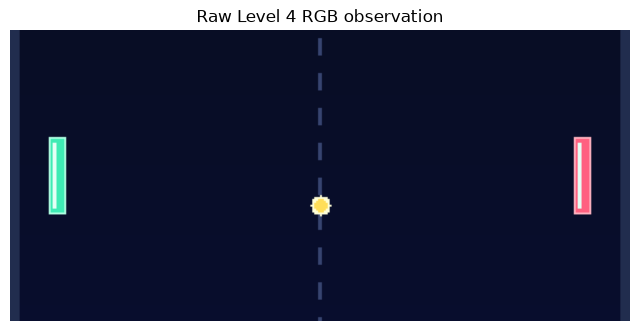

In [2]:
inspection_env = PaddleDuelEnv(
    level=4,
    opponent="weak",
    max_seconds=6,
    render_scale=2,
)

sample_frame, sample_info = inspection_env.reset(seed=0)

print("Observation type:", type(sample_frame))
print("Observation shape:", sample_frame.shape)
print("Observation dtype:", sample_frame.dtype)
print("Pixel range:", sample_frame.min(), "to", sample_frame.max())

plt.figure(figsize=(8, 4))
plt.imshow(sample_frame)
plt.axis("off")
plt.title("Raw Level 4 RGB observation")
plt.show()


## Pixel preprocessing and frame stacking


Processed frame shape: (84, 84)
Processed dtype: uint8
Stacked state shape: (4, 84, 84)
Stacked dtype: uint8


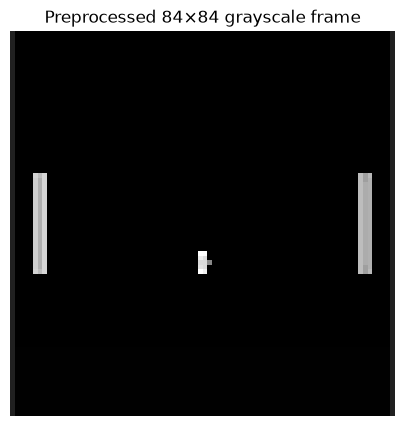

In [3]:
FRAME_HEIGHT = 84
FRAME_WIDTH = 84
FRAME_STACK = 4
N_ACTIONS = 3


def preprocess_frame(frame: np.ndarray) -> np.ndarray:
    """Convert an RGB frame to a resized 84×84 uint8 grayscale frame."""
    if frame.ndim != 3 or frame.shape[2] != 3:
        raise ValueError(
            f"Expected RGB frame with shape (H, W, 3), got {frame.shape}"
        )

    frame_tensor = torch.as_tensor(
        frame,
        dtype=torch.float32,
    ).permute(2, 0, 1).unsqueeze(0)

    # Standard luminance conversion.
    red = frame_tensor[:, 0:1]
    green = frame_tensor[:, 1:2]
    blue = frame_tensor[:, 2:3]

    grayscale = (
        0.299 * red
        + 0.587 * green
        + 0.114 * blue
    )

    resized = F.interpolate(
        grayscale,
        size=(FRAME_HEIGHT, FRAME_WIDTH),
        mode="bilinear",
        align_corners=False,
    )

    processed = (
        resized.squeeze(0)
        .squeeze(0)
        .clamp(0, 255)
        .byte()
        .cpu()
        .numpy()
    )

    return processed


class FrameStacker:
    def __init__(self, stack_size: int = FRAME_STACK):
        self.stack_size = int(stack_size)
        self.frames = deque(maxlen=self.stack_size)

    def reset(self, first_frame: np.ndarray) -> np.ndarray:
        processed = preprocess_frame(first_frame)
        self.frames.clear()

        for _ in range(self.stack_size):
            self.frames.append(processed.copy())

        return self.get_state()

    def append(self, frame: np.ndarray) -> np.ndarray:
        self.frames.append(preprocess_frame(frame))
        return self.get_state()

    def get_state(self) -> np.ndarray:
        if len(self.frames) != self.stack_size:
            raise RuntimeError("Frame stack is not initialized.")

        return np.stack(self.frames, axis=0).astype(np.uint8)


sample_processed = preprocess_frame(sample_frame)
sample_stacker = FrameStacker()
sample_stack = sample_stacker.reset(sample_frame)

print("Processed frame shape:", sample_processed.shape)
print("Processed dtype:", sample_processed.dtype)
print("Stacked state shape:", sample_stack.shape)
print("Stacked dtype:", sample_stack.dtype)

plt.figure(figsize=(5, 5))
plt.imshow(sample_processed, cmap="gray")
plt.axis("off")
plt.title("Preprocessed 84×84 grayscale frame")
plt.show()


## Replay buffer

Pixel states are stored as `uint8` arrays to reduce memory use. They are converted to floating-point tensors and normalized to `[0, 1]` only when sampled for training.


In [4]:
class PixelReplayBuffer:
    def __init__(self, capacity: int = 30_000, seed: int = 0):
        if capacity <= 0:
            raise ValueError("capacity must be positive.")

        self.buffer = deque(maxlen=capacity)
        self.rng = random.Random(seed)

    def push(
        self,
        state,
        action: int,
        reward: float,
        next_state,
        done: bool,
    ) -> None:
        self.buffer.append(
            (
                np.asarray(state, dtype=np.uint8),
                int(action),
                float(reward),
                np.asarray(next_state, dtype=np.uint8),
                bool(done),
            )
        )

    def sample(self, batch_size: int):
        if batch_size > len(self.buffer):
            raise ValueError(
                "Cannot sample more transitions than are stored."
            )

        transitions = self.rng.sample(
            list(self.buffer),
            batch_size,
        )

        states, actions, rewards, next_states, dones = zip(
            *transitions
        )

        return (
            np.stack(states),
            np.asarray(actions, dtype=np.int64),
            np.asarray(rewards, dtype=np.float32),
            np.stack(next_states),
            np.asarray(dones, dtype=np.float32),
        )

    def __len__(self) -> int:
        return len(self.buffer)


## CNN Q-network


In [5]:
class CNNQNetwork(nn.Module):
    def __init__(
        self,
        input_channels: int = FRAME_STACK,
        n_actions: int = N_ACTIONS,
    ):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(
                input_channels,
                32,
                kernel_size=8,
                stride=4,
            ),
            nn.ReLU(),
            nn.Conv2d(
                32,
                64,
                kernel_size=4,
                stride=2,
            ),
            nn.ReLU(),
            nn.Conv2d(
                64,
                64,
                kernel_size=3,
                stride=1,
            ),
            nn.ReLU(),
        )

        with torch.no_grad():
            dummy = torch.zeros(
                1,
                input_channels,
                FRAME_HEIGHT,
                FRAME_WIDTH,
            )
            flattened_size = int(
                np.prod(self.features(dummy).shape[1:])
            )

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flattened_size, 512),
            nn.ReLU(),
            nn.Linear(512, n_actions),
        )

    def forward(self, x):
        x = self.features(x)
        return self.head(x)


test_cnn = CNNQNetwork().to(DEVICE)
test_input = torch.zeros(
    (1, FRAME_STACK, FRAME_HEIGHT, FRAME_WIDTH),
    dtype=torch.float32,
    device=DEVICE,
)

print(test_cnn)
print("Test output shape:", test_cnn(test_input).shape)


CNNQNetwork(
  (features): Sequential(
    (0): Conv2d(4, 32, kernel_size=(8, 8), stride=(4, 4))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2))
    (3): ReLU()
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (5): ReLU()
  )
  (head): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=3, bias=True)
  )
)
Test output shape: torch.Size([1, 3])


## CNN-DQN agent


In [6]:
class CNNDQNAgent(BaseAgent):
    def __init__(
        self,
        input_channels: int = FRAME_STACK,
        n_actions: int = N_ACTIONS,
        learning_rate: float = 1e-4,
        gamma: float = 0.99,
        epsilon_start: float = 1.0,
        epsilon_min: float = 0.05,
        epsilon_decay: float = 0.99995,
        buffer_capacity: int = 30_000,
        batch_size: int = 64,
        min_buffer_size: int = 5_000,
        target_update_steps: int = 2_000,
        train_frequency: int = 4,
        name: str = "CNN-DQN",
        seed: int = 0,
        device=DEVICE,
    ):
        self.name = name
        self.input_channels = int(input_channels)
        self.n_actions = int(n_actions)
        self.gamma = float(gamma)

        self.epsilon_start = float(epsilon_start)
        self.epsilon_min = float(epsilon_min)
        self.epsilon_decay = float(epsilon_decay)
        self.epsilon = float(epsilon_start)

        self.batch_size = int(batch_size)
        self.min_buffer_size = int(min_buffer_size)
        self.target_update_steps = int(target_update_steps)
        self.train_frequency = int(train_frequency)

        self.device = device
        self.rng = np.random.default_rng(seed)

        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)

        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)

        self.policy_net = CNNQNetwork(
            input_channels=input_channels,
            n_actions=n_actions,
        ).to(self.device)

        self.target_net = CNNQNetwork(
            input_channels=input_channels,
            n_actions=n_actions,
        ).to(self.device)

        self.target_net.load_state_dict(
            self.policy_net.state_dict()
        )
        self.target_net.eval()

        self.optimizer = optim.Adam(
            self.policy_net.parameters(),
            lr=learning_rate,
        )

        self.replay_buffer = PixelReplayBuffer(
            capacity=buffer_capacity,
            seed=seed,
        )

        self.frame_stacker = FrameStacker(
            stack_size=input_channels
        )

        self.environment_steps = 0
        self.optimization_steps = 0
        self.current_state = None

    def reset(self) -> None:
        self.frame_stacker = FrameStacker(
            stack_size=self.input_channels
        )
        self.current_state = None

    def reset_exploration(self) -> None:
        self.epsilon = self.epsilon_start

    def decay_exploration(self) -> None:
        self.epsilon = max(
            self.epsilon_min,
            self.epsilon * self.epsilon_decay,
        )

    def initialize_state(self, observation) -> np.ndarray:
        self.current_state = self.frame_stacker.reset(
            observation
        )
        return self.current_state

    def append_observation(self, observation) -> np.ndarray:
        self.current_state = self.frame_stacker.append(
            observation
        )
        return self.current_state

    def select_action_from_state(
        self,
        state,
        training: bool = False,
        force_random: bool = False,
    ) -> int:
        if force_random:
            return int(self.rng.integers(self.n_actions))

        if training and self.rng.random() < self.epsilon:
            return int(self.rng.integers(self.n_actions))

        state_tensor = torch.as_tensor(
            state,
            dtype=torch.float32,
            device=self.device,
        ).unsqueeze(0) / 255.0

        self.policy_net.eval()

        with torch.no_grad():
            q_values = self.policy_net(state_tensor)

        if training:
            self.policy_net.train()

        return int(torch.argmax(q_values, dim=1).item())

    def select_action(
        self,
        observation,
        info: Optional[Dict[str, Any]] = None,
        training: bool = False,
    ) -> int:
        if self.current_state is None:
            state = self.initialize_state(observation)
        else:
            state = self.append_observation(observation)

        return self.select_action_from_state(
            state,
            training=training,
        )

    def store_transition(
        self,
        state,
        action,
        reward,
        next_state,
        done,
    ) -> None:
        self.replay_buffer.push(
            state,
            action,
            reward,
            next_state,
            done,
        )

    def optimize(self) -> Optional[float]:
        if len(self.replay_buffer) < self.min_buffer_size:
            return None

        if self.environment_steps % self.train_frequency != 0:
            return None

        (
            states,
            actions,
            rewards,
            next_states,
            dones,
        ) = self.replay_buffer.sample(self.batch_size)

        states_tensor = torch.as_tensor(
            states,
            dtype=torch.float32,
            device=self.device,
        ) / 255.0

        actions_tensor = torch.as_tensor(
            actions,
            dtype=torch.long,
            device=self.device,
        ).unsqueeze(1)

        rewards_tensor = torch.as_tensor(
            rewards,
            dtype=torch.float32,
            device=self.device,
        ).unsqueeze(1)

        next_states_tensor = torch.as_tensor(
            next_states,
            dtype=torch.float32,
            device=self.device,
        ) / 255.0

        dones_tensor = torch.as_tensor(
            dones,
            dtype=torch.float32,
            device=self.device,
        ).unsqueeze(1)

        current_q_values = self.policy_net(
            states_tensor
        ).gather(1, actions_tensor)

        with torch.no_grad():
            next_q_values = self.target_net(
                next_states_tensor
            ).max(dim=1, keepdim=True).values

            target_q_values = (
                rewards_tensor
                + self.gamma
                * (1.0 - dones_tensor)
                * next_q_values
            )

        loss = F.smooth_l1_loss(
            current_q_values,
            target_q_values,
        )

        self.optimizer.zero_grad()
        loss.backward()

        nn.utils.clip_grad_norm_(
            self.policy_net.parameters(),
            max_norm=10.0,
        )

        self.optimizer.step()
        self.optimization_steps += 1

        if (
            self.environment_steps
            % self.target_update_steps
            == 0
        ):
            self.target_net.load_state_dict(
                self.policy_net.state_dict()
            )

        return float(loss.item())

    def save(self, path) -> None:
        checkpoint = {
            "name": self.name,
            "input_channels": self.input_channels,
            "n_actions": self.n_actions,
            "gamma": self.gamma,
            "epsilon_start": self.epsilon_start,
            "epsilon_min": self.epsilon_min,
            "epsilon_decay": self.epsilon_decay,
            "epsilon": self.epsilon,
            "batch_size": self.batch_size,
            "min_buffer_size": self.min_buffer_size,
            "target_update_steps": self.target_update_steps,
            "train_frequency": self.train_frequency,
            "environment_steps": self.environment_steps,
            "optimization_steps": self.optimization_steps,
            "policy_state_dict": self.policy_net.state_dict(),
            "target_state_dict": self.target_net.state_dict(),
            "optimizer_state_dict": self.optimizer.state_dict(),
        }

        torch.save(checkpoint, path)

    @classmethod
    def load(
        cls,
        path,
        seed: int = 0,
        device=DEVICE,
    ):
        checkpoint = torch.load(
            path,
            map_location=device,
        )

        agent = cls(
            input_channels=checkpoint["input_channels"],
            n_actions=checkpoint["n_actions"],
            gamma=checkpoint["gamma"],
            epsilon_start=checkpoint["epsilon_start"],
            epsilon_min=checkpoint["epsilon_min"],
            epsilon_decay=checkpoint["epsilon_decay"],
            batch_size=checkpoint["batch_size"],
            min_buffer_size=checkpoint["min_buffer_size"],
            target_update_steps=checkpoint["target_update_steps"],
            train_frequency=checkpoint["train_frequency"],
            name=checkpoint["name"],
            seed=seed,
            device=device,
        )

        agent.policy_net.load_state_dict(
            checkpoint["policy_state_dict"]
        )
        agent.target_net.load_state_dict(
            checkpoint["target_state_dict"]
        )
        agent.optimizer.load_state_dict(
            checkpoint["optimizer_state_dict"]
        )

        agent.epsilon = checkpoint["epsilon"]
        agent.environment_steps = checkpoint["environment_steps"]
        agent.optimization_steps = checkpoint["optimization_steps"]

        return agent


## Training loop

The first 400 episodes use random actions to populate the replay buffer. The CNN still learns from those transitions once the minimum replay size has been reached.

Because CNN optimization is more expensive than MLP optimization, the default buffer and batch sizes are smaller than in the feature-based notebook.


In [7]:
def train_cnn_dqn(
    agent: CNNDQNAgent,
    n_episodes: int = 2000,
    seed: int = 0,
    opponent: str = "weak",
    max_seconds: int = 60,
    render_scale: int = 2,
    forced_random_episodes: int = 400,
    print_every: int = 100,
):
    history = {
        "rewards": [],
        "wins": [],
        "hits": [],
        "steps": [],
        "movement_actions": [],
        "stay_actions": [],
        "losses": [],
        "epsilon": [],
    }

    agent.reset_exploration()
    start_time = time.perf_counter()

    for episode_idx in range(n_episodes):
        env = PaddleDuelEnv(
            level=4,
            opponent=opponent,
            max_seconds=max_seconds,
            render_scale=render_scale,
        )

        observation, info = env.reset(
            seed=seed + episode_idx
        )

        agent.reset()
        state = agent.initialize_state(observation)

        terminated = False
        truncated = False
        total_reward = 0.0
        episode_losses = []
        movement_actions = 0
        stay_actions = 0
        steps = 0

        force_random = (
            episode_idx < forced_random_episodes
        )

        while not (terminated or truncated):
            action = agent.select_action_from_state(
                state,
                training=True,
                force_random=force_random,
            )

            if action in (ACTION_UP, ACTION_DOWN):
                movement_actions += 1
            else:
                stay_actions += 1

            (
                next_observation,
                reward,
                terminated,
                truncated,
                next_info,
            ) = env.step(action)

            done = terminated or truncated
            next_state = agent.append_observation(
                next_observation
            )

            agent.store_transition(
                state,
                action,
                reward,
                next_state,
                done,
            )

            agent.environment_steps += 1
            loss = agent.optimize()

            if loss is not None:
                episode_losses.append(loss)

            state = next_state.copy()
            info = next_info
            total_reward += float(reward)
            steps += 1

            if not force_random:
                agent.decay_exploration()

        history["rewards"].append(total_reward)
        history["wins"].append(
            float(info.get("winner") == "left")
        )
        history["hits"].append(
            int(info.get("left_hits", 0))
        )
        history["steps"].append(steps)
        history["movement_actions"].append(
            movement_actions
        )
        history["stay_actions"].append(stay_actions)
        history["losses"].append(
            float(np.mean(episode_losses))
            if episode_losses
            else np.nan
        )
        history["epsilon"].append(agent.epsilon)

        if (
            (episode_idx + 1) % print_every == 0
            or episode_idx == 0
        ):
            start_index = max(
                0,
                episode_idx - print_every + 1,
            )
            end_index = episode_idx + 1

            recent_reward = np.mean(
                history["rewards"][start_index:end_index]
            )
            recent_win_rate = np.mean(
                history["wins"][start_index:end_index]
            )

            print(
                f"Episode {episode_idx + 1:4d}/{n_episodes} | "
                f"reward={recent_reward:7.3f} | "
                f"win_rate={recent_win_rate:6.3f} | "
                f"epsilon={agent.epsilon:6.3f} | "
                f"buffer={len(agent.replay_buffer):6d}"
            )

    history["training_seconds"] = (
        time.perf_counter() - start_time
    )

    return history


## Configure and train CNN-DQN


In [8]:
CNN_DQN_CONFIG = {
    "learning_rate": 1e-4,
    "gamma": 0.99,
    "epsilon_start": 1.0,
    "epsilon_min": 0.05,
    "epsilon_decay": 0.99995,
    "buffer_capacity": 30_000,
    "batch_size": 64,
    "min_buffer_size": 5_000,
    "target_update_steps": 2_000,
    "train_frequency": 4,
}

N_TRAIN_EPISODES = 2000
FORCED_RANDOM_EPISODES = 400
TRAIN_OPPONENT = "weak"
TRAIN_SEED = 0

cnn_agent = CNNDQNAgent(
    name="Level 4 CNN-DQN",
    seed=14,
    **CNN_DQN_CONFIG,
)

cnn_history = train_cnn_dqn(
    cnn_agent,
    n_episodes=N_TRAIN_EPISODES,
    seed=TRAIN_SEED,
    opponent=TRAIN_OPPONENT,
    forced_random_episodes=FORCED_RANDOM_EPISODES,
)

print(
    "\nTraining complete."
    f"\nTime: {cnn_history['training_seconds']:.1f} seconds"
    f"\nEnvironment steps: {cnn_agent.environment_steps:,}"
    f"\nOptimization steps: {cnn_agent.optimization_steps:,}"
    f"\nReplay-buffer size: {len(cnn_agent.replay_buffer):,}"
)


Episode    1/2000 | reward= -0.021 | win_rate= 0.000 | epsilon= 1.000 | buffer=    36
Episode  100/2000 | reward=  0.859 | win_rate= 0.090 | epsilon= 1.000 | buffer= 10879
Episode  200/2000 | reward=  1.655 | win_rate= 0.170 | epsilon= 1.000 | buffer= 24205
Episode  300/2000 | reward=  0.753 | win_rate= 0.080 | epsilon= 1.000 | buffer= 30000
Episode  400/2000 | reward=  1.453 | win_rate= 0.150 | epsilon= 1.000 | buffer= 30000
Episode  500/2000 | reward=  2.251 | win_rate= 0.230 | epsilon= 0.450 | buffer= 30000
Episode  600/2000 | reward=  1.455 | win_rate= 0.150 | epsilon= 0.224 | buffer= 30000
Episode  700/2000 | reward=  1.449 | win_rate= 0.150 | epsilon= 0.106 | buffer= 30000
Episode  800/2000 | reward=  2.148 | win_rate= 0.220 | epsilon= 0.050 | buffer= 30000
Episode  900/2000 | reward=  1.857 | win_rate= 0.190 | epsilon= 0.050 | buffer= 30000
Episode 1000/2000 | reward=  1.639 | win_rate= 0.170 | epsilon= 0.050 | buffer= 30000
Episode 1100/2000 | reward=  1.442 | win_rate= 0.150 |

### Smoke test before full training

CNN training is substantially more expensive than Feature-DQN training. First test the pipeline with:

```python
N_TRAIN_EPISODES = 20
FORCED_RANDOM_EPISODES = 5
```

For this smoke test, temporarily reduce:

```python
"min_buffer_size": 500
```

After confirming that the buffer fills, losses become finite, evaluation runs, and replay works, restore the full configuration.


## Training curves


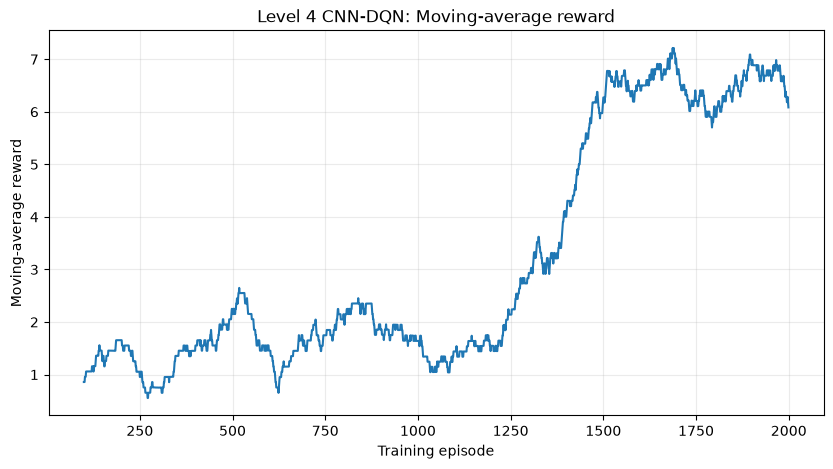

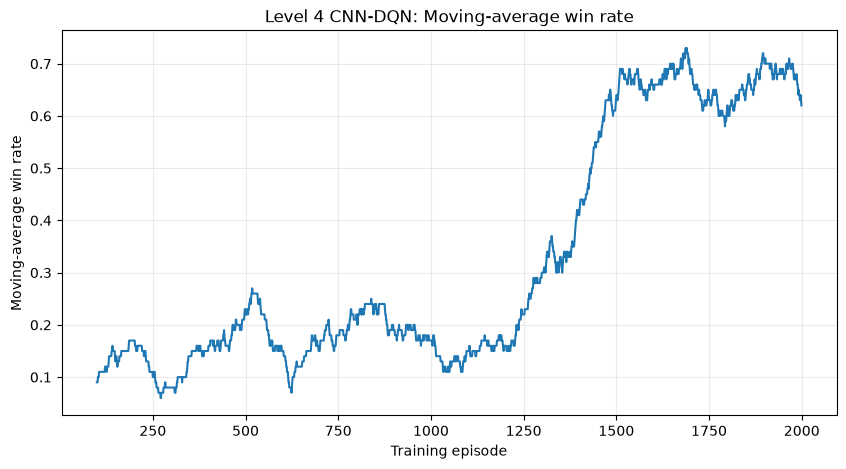

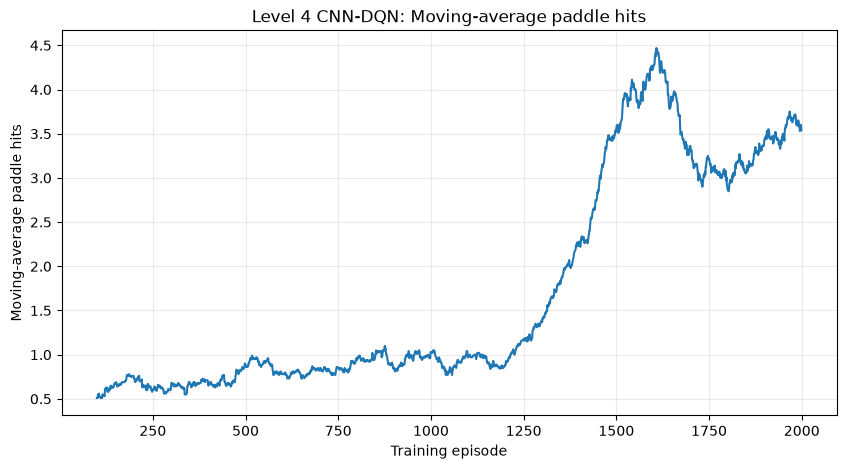

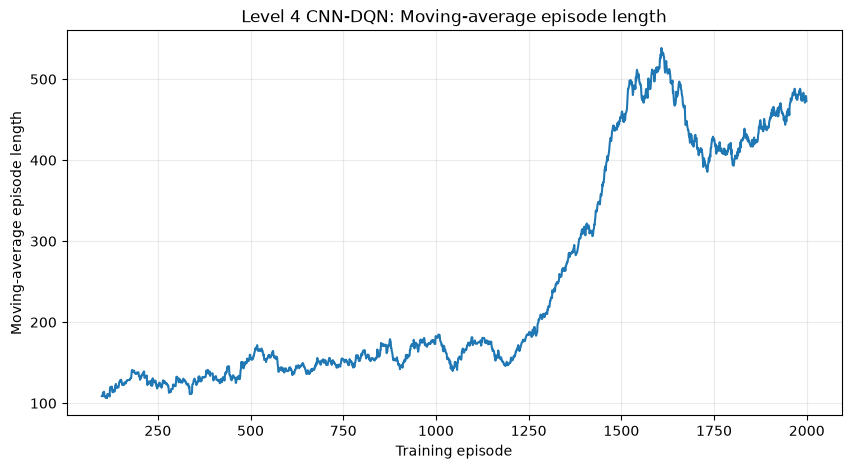

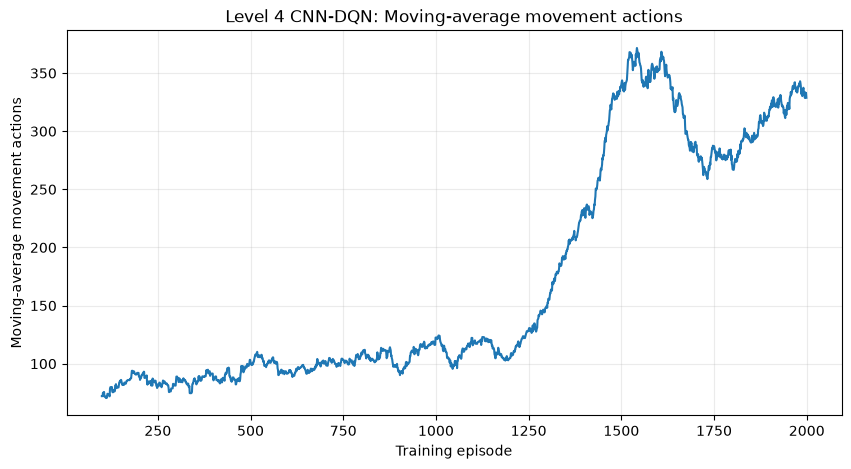

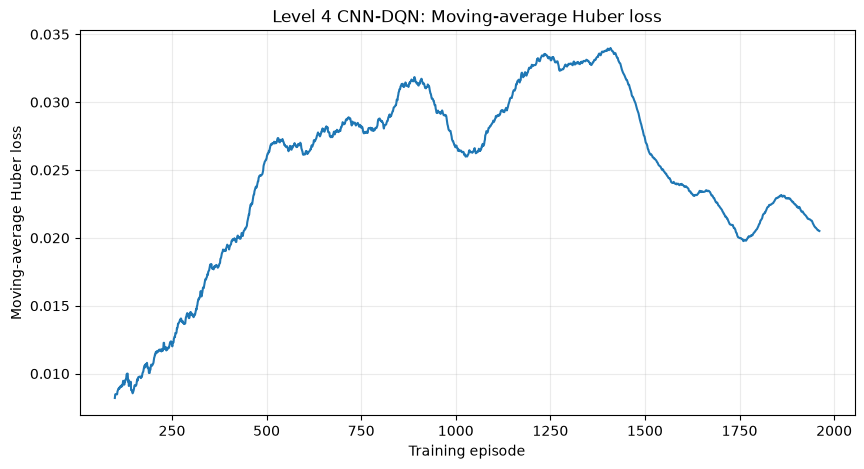

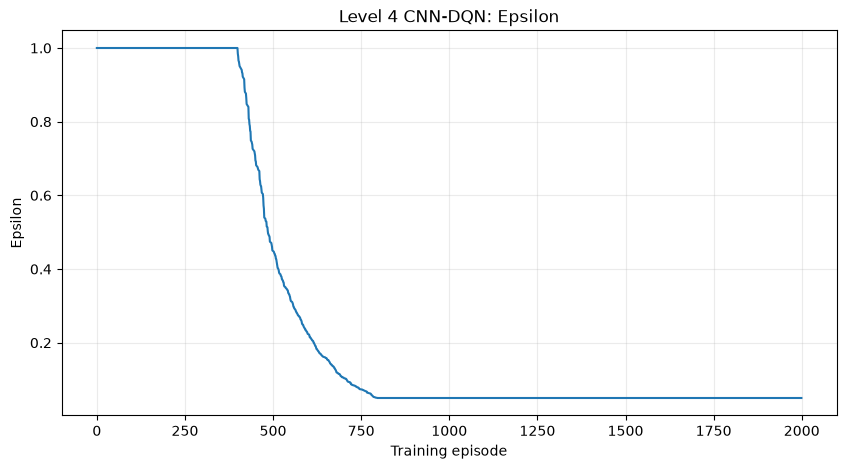

In [9]:
def moving_average(values, window=100):
    values = np.asarray(values, dtype=float)

    if len(values) < window:
        return values

    kernel = np.ones(window, dtype=float) / window
    return np.convolve(values, kernel, mode="valid")


def plot_history(
    history,
    metric,
    ylabel,
    window=100,
    ignore_nan=False,
):
    values = np.asarray(history[metric], dtype=float)

    if ignore_nan:
        valid_indices = np.flatnonzero(np.isfinite(values))
        values = values[valid_indices]

    if len(values) == 0:
        print(f"No finite values available for {metric}.")
        return

    smoothed = moving_average(values, window)

    start = window - 1 if len(values) >= window else 0
    x = np.arange(start, start + len(smoothed))

    plt.figure(figsize=(10, 5))
    plt.plot(x, smoothed)
    plt.xlabel("Training episode")
    plt.ylabel(ylabel)
    plt.title(f"Level 4 CNN-DQN: {ylabel}")
    plt.grid(alpha=0.25)
    plt.show()


plot_history(
    cnn_history,
    "rewards",
    "Moving-average reward",
)

plot_history(
    cnn_history,
    "wins",
    "Moving-average win rate",
)

plot_history(
    cnn_history,
    "hits",
    "Moving-average paddle hits",
)

plot_history(
    cnn_history,
    "steps",
    "Moving-average episode length",
)

plot_history(
    cnn_history,
    "movement_actions",
    "Moving-average movement actions",
)

plot_history(
    cnn_history,
    "losses",
    "Moving-average Huber loss",
    ignore_nan=True,
)

plot_history(
    cnn_history,
    "epsilon",
    "Epsilon",
    window=1,
)


## Evaluation on unseen seeds


In [10]:
def evaluate_cnn_dqn(
    agent,
    opponent: str = "weak",
    n_episodes: int = 200,
    seed: int = 10_000,
    max_seconds: int = 60,
    render_scale: int = 2,
):
    rewards = []
    wins = []
    hits = []
    steps = []
    movement_counts = []
    stay_counts = []
    misses = []
    timeouts = []

    agent.policy_net.eval()

    for episode_idx in range(n_episodes):
        env = PaddleDuelEnv(
            level=4,
            opponent=opponent,
            max_seconds=max_seconds,
            render_scale=render_scale,
        )

        observation, info = env.reset(
            seed=seed + episode_idx
        )

        agent.reset()

        terminated = False
        truncated = False
        total_reward = 0.0
        movement_count = 0
        stay_count = 0

        while not (terminated or truncated):
            action = agent.select_action(
                observation,
                info=info,
                training=False,
            )

            if action in (ACTION_UP, ACTION_DOWN):
                movement_count += 1
            else:
                stay_count += 1

            (
                observation,
                reward,
                terminated,
                truncated,
                info,
            ) = env.step(action)

            total_reward += float(reward)

        rewards.append(total_reward)
        wins.append(
            float(info.get("winner") == "left")
        )
        hits.append(
            int(info.get("left_hits", 0))
        )
        steps.append(
            int(info.get("steps", 0))
        )
        movement_counts.append(movement_count)
        stay_counts.append(stay_count)
        misses.append(
            float(info.get("done_reason") == "right_scored")
        )
        timeouts.append(
            float(info.get("done_reason") == "timeout")
        )

    return {
        "mean_reward": float(np.mean(rewards)),
        "std_reward": float(np.std(rewards)),
        "win_rate": float(np.mean(wins)),
        "mean_hits": float(np.mean(hits)),
        "std_hits": float(np.std(hits)),
        "max_hits": int(np.max(hits)),
        "mean_steps": float(np.mean(steps)),
        "mean_movement_actions": float(
            np.mean(movement_counts)
        ),
        "mean_stay_actions": float(
            np.mean(stay_counts)
        ),
        "miss_rate": float(np.mean(misses)),
        "timeout_rate": float(np.mean(timeouts)),
    }


N_EVAL_EPISODES = 200
EVAL_SEED = 10_000

cnn_evaluation_result = evaluate_cnn_dqn(
    cnn_agent,
    opponent=TRAIN_OPPONENT,
    n_episodes=N_EVAL_EPISODES,
    seed=EVAL_SEED,
)

print("===== CNN-DQN EVALUATION =====")
for key, value in cnn_evaluation_result.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")


===== CNN-DQN EVALUATION =====
mean_reward: 6.9040
std_reward: 4.5839
win_rate: 0.7000
mean_hits: 3.6700
std_hits: 2.6117
max_hits: 15
mean_steps: 482.3550
mean_movement_actions: 316.1850
mean_stay_actions: 166.1700
miss_rate: 0.3000
timeout_rate: 0.0000


## Random and tracking baseline comparison


In [11]:
def evaluate_generic_agent(
    generic_agent,
    opponent: str = "weak",
    n_episodes: int = 200,
    seed: int = 10_000,
    max_seconds: int = 60,
    render_scale: int = 2,
):
    rewards = []
    wins = []
    steps = []

    for episode_idx in range(n_episodes):
        env = PaddleDuelEnv(
            level=4,
            opponent=opponent,
            max_seconds=max_seconds,
            render_scale=render_scale,
        )

        observation, info = env.reset(
            seed=seed + episode_idx
        )

        generic_agent.reset()

        terminated = False
        truncated = False
        total_reward = 0.0

        while not (terminated or truncated):
            action = generic_agent.select_action(
                observation,
                info=info,
                training=False,
            )

            (
                observation,
                reward,
                terminated,
                truncated,
                info,
            ) = env.step(action)

            total_reward += float(reward)

        rewards.append(total_reward)
        wins.append(
            float(info.get("winner") == "left")
        )
        steps.append(
            int(info.get("steps", 0))
        )

    return {
        "mean_reward": float(np.mean(rewards)),
        "std_reward": float(np.std(rewards)),
        "win_rate": float(np.mean(wins)),
        "mean_steps": float(np.mean(steps)),
    }


baseline_results = {
    "CNN-DQN": {
        key: cnn_evaluation_result[key]
        for key in [
            "mean_reward",
            "std_reward",
            "win_rate",
            "mean_steps",
        ]
    },
    "Random Agent": evaluate_generic_agent(
        RandomAgent(seed=101),
        opponent=TRAIN_OPPONENT,
        n_episodes=N_EVAL_EPISODES,
        seed=EVAL_SEED,
    ),
    "Tracking Agent": evaluate_generic_agent(
        TrackingAgent(seed=202),
        opponent=TRAIN_OPPONENT,
        n_episodes=N_EVAL_EPISODES,
        seed=EVAL_SEED,
    ),
}

for name, result in baseline_results.items():
    print(f"\n{name}")
    for key, value in result.items():
        print(f"  {key}: {value:.4f}")



CNN-DQN
  mean_reward: 6.9040
  std_reward: 4.5839
  win_rate: 0.7000
  mean_steps: 482.3550

Random Agent
  mean_reward: 1.5015
  std_reward: 3.6135
  win_rate: 0.1550
  mean_steps: 141.7500

Tracking Agent
  mean_reward: 7.6266
  std_reward: 4.3166
  win_rate: 0.7550
  mean_steps: 741.7850


## Save and reload the CNN-DQN model


In [12]:
SAVE_DIR = PROJECT_ROOT / "saved_agents"
SAVE_DIR.mkdir(exist_ok=True)

SAVE_PATH = SAVE_DIR / "cnn_dqn_level4.pt"

cnn_agent.save(SAVE_PATH)
print("Saved model to:", SAVE_PATH)

reloaded_cnn_agent = CNNDQNAgent.load(
    SAVE_PATH,
    seed=999,
    device=DEVICE,
)

print(
    "Reloaded:",
    reloaded_cnn_agent.name,
    "| environment steps:",
    reloaded_cnn_agent.environment_steps,
    "| optimization steps:",
    reloaded_cnn_agent.optimization_steps,
)


Saved model to: d:\Users\MANAN\Downloads\Project Starter Code_new\saved_agents\cnn_dqn_level4.pt
Reloaded: Level 4 CNN-DQN | environment steps: 500379 | optimization steps: 123845


## Verify the reloaded model


In [13]:
reloaded_cnn_result = evaluate_cnn_dqn(
    reloaded_cnn_agent,
    opponent=TRAIN_OPPONENT,
    n_episodes=50,
    seed=20_000,
)

print("===== RELOADED CNN-DQN EVALUATION =====")
for key, value in reloaded_cnn_result.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")


===== RELOADED CNN-DQN EVALUATION =====
mean_reward: 7.1185
std_reward: 4.5078
win_rate: 0.7200
mean_hits: 3.4400
std_hits: 2.2905
max_hits: 10
mean_steps: 447.6000
mean_movement_actions: 287.8600
mean_stay_actions: 159.7400
miss_rate: 0.2800
timeout_rate: 0.0000


## Replay diagnostics


In [14]:
REPLAY_SEED = 22
REPLAY_SECONDS = 10

cnn_episode = record_episode(
    PaddleDuelEnv(
        level=4,
        opponent=TRAIN_OPPONENT,
        max_seconds=REPLAY_SECONDS,
        render_scale=2,
    ),
    cnn_agent,
    seed=REPLAY_SEED,
)

action_counts = Counter(cnn_episode.actions)
positions = [
    info["left_paddle_y"]
    for info in cnn_episode.infos
]
final_info = cnn_episode.infos[-1]

print("===== CNN-DQN REPLAY =====")
print("ACTION COUNTS")
print(f"  UP   : {action_counts[ACTION_UP]}")
print(f"  DOWN : {action_counts[ACTION_DOWN]}")
print(f"  STAY : {action_counts[ACTION_STAY]}")

print("PADDLE MOVEMENT")
print(f"  Initial position : {positions[0]:.1f}")
print(f"  Minimum position : {min(positions):.1f}")
print(f"  Maximum position : {max(positions):.1f}")
print(
    "  Position range   : "
    f"{max(positions) - min(positions):.1f} pixels"
)

print("EPISODE RESULT")
print(f"  Hits       : {final_info.get('left_hits', 0)}")
print(f"  Reward     : {cnn_episode.total_reward:.4f}")
print(f"  Steps      : {final_info.get('steps')}")
print(f"  End reason : {final_info.get('done_reason')}")
print(f"  Winner     : {final_info.get('winner')}")


===== CNN-DQN REPLAY =====
ACTION COUNTS
  UP   : 44
  DOWN : 32
  STAY : 62
PADDLE MOVEMENT
  Initial position : 154.0
  Minimum position : 56.0
  Maximum position : 168.0
  Position range   : 112.0 pixels
EPISODE RESULT
  Hits       : 1
  Reward     : 9.9840
  Steps      : 138
  End reason : left_scored
  Winner     : left


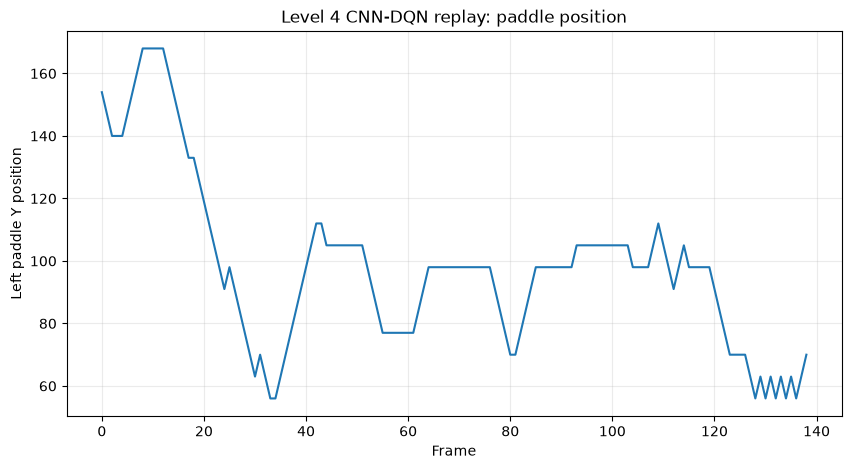

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(positions)
plt.xlabel("Frame")
plt.ylabel("Left paddle Y position")
plt.title("Level 4 CNN-DQN replay: paddle position")
plt.grid(alpha=0.25)
plt.show()


## Animate the CNN-DQN replay


In [16]:
animate_episode(cnn_episode, interval=30)


## Comparison checklist

After running this notebook, compare CNN-DQN against the Feature-DQN baseline using identical evaluation seeds:

1. mean reward,
2. win rate,
3. paddle hits,
4. episode length,
5. movement actions,
6. training time,
7. model stability,
8. replay behavior,
9. performance after saving and reloading.

The Feature-DQN baseline previously achieved approximately:

- mean reward: `1.98`,
- win rate: `20.5%`,
- mean hits: `1.08`,
- mean steps: `172`.

The CNN-DQN should be judged against the complete evaluation rather than one replay. Pixel learning may initially require more episodes than feature-based learning because the CNN must learn both perception and control.
